#**NAME: KALAIVANI D**
#**REG NO: 212224060113**
#**EXP NAME: NATURAL SAMPLING**

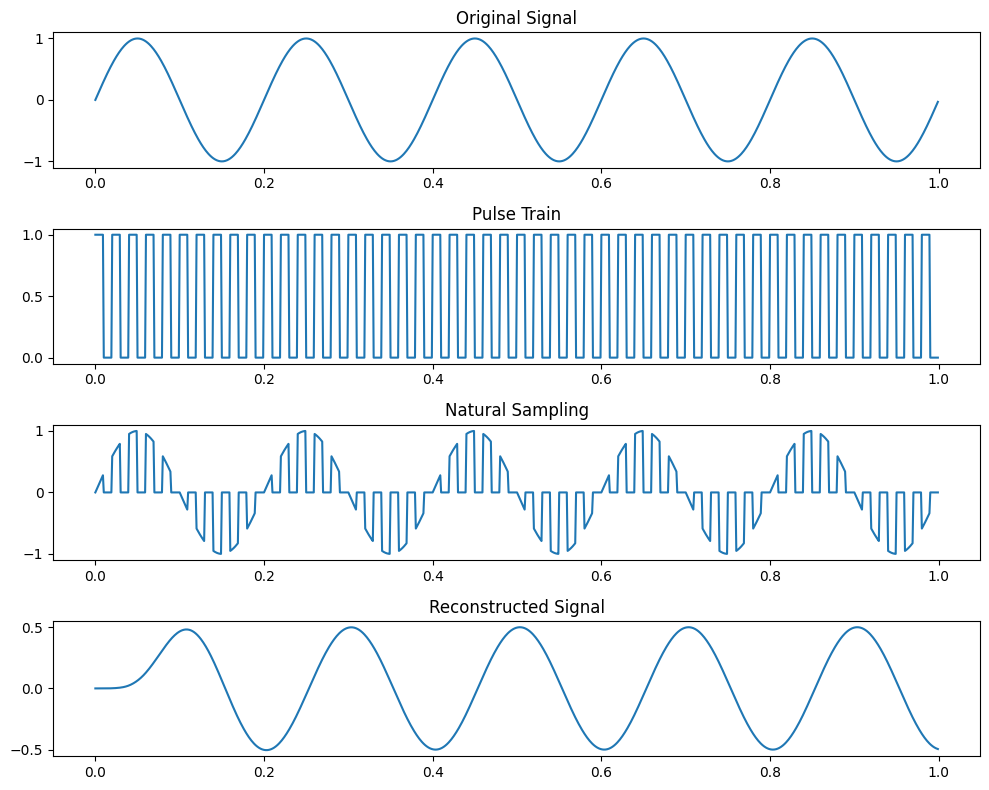

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Parameters
fs = 1000
T = 1
fm = 5

t = np.arange(0, T, 1/fs)

# Message Signal
message = np.sin(2 * np.pi * fm * t)

# Pulse Train
pulse_rate = 50
pulse_train = np.zeros_like(t)

pulse_width = int(fs / pulse_rate / 2)

for i in range(0, len(t), int(fs / pulse_rate)):
    pulse_train[i:i+pulse_width] = 1

# Natural Sampling
natural_signal = message * pulse_train

# Low-pass Filter
def lowpass(signal, cutoff, fs):
    nyq = 0.5 * fs
    normal = cutoff / nyq
    b, a = butter(5, normal, btype='low')
    return lfilter(b, a, signal)

reconstructed = lowpass(natural_signal, 10, fs)

# Plots
plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(t, message)
plt.title("Original Signal")

plt.subplot(4,1,2)
plt.plot(t, pulse_train)
plt.title("Pulse Train")

plt.subplot(4,1,3)
plt.plot(t, natural_signal)
plt.title("Natural Sampling")

plt.subplot(4,1,4)
plt.plot(t, reconstructed)
plt.title("Reconstructed Signal")

plt.tight_layout()
plt.show()